# HW 1: Minimal Pair with Implicit Causality
### COSC 426: Fall 2025, Colgate University

Use this notebook to load in the results from your experiment, display them, and answer the question(s). Feel free to add as many code and markdown chunks as you would like in each of the sub-sections. 

**If you use any external resources (e.g., code snippets, reference articles), please cite them in comments or text!**

## Setup and data loading
In this section, load the data, import any packages or files, and define any functions you need.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    df_verbs = pd.read_csv('data.csv')
except FileNotFoundError:
    print("\n'data.csv' not found.")
    exit() 

# df_verbs = df_verbs[['Verb', 'Word Frequency (CELEX)', 'Semantic Category', 'IVC']].copy()
# df_verbs.rename(columns={
#     'Verb': 'verb',
#     'Word Frequency (CELEX)': 'frequency',
#     'Semantic Category': 'semantic_class_detailed',
#     'IVC': 'bias'
# }, inplace=True)

df_verbs = df_verbs[['Verb', 'Word Frequency (CELEX)', 'Semantic Category']].copy()
df_verbs.rename(columns={
    'Verb': 'verb',
    'Word Frequency (CELEX)': 'frequency',
    'Semantic Category': 'semantic_class_detailed'
}, inplace=True)

df_verbs.dropna(inplace=True)
df_verbs['verb'] = df_verbs['verb'].str.strip()

def map_semantic_class(detailed_class):
    if detailed_class in ['StimExp', 'ExpStim']:
        return 'Psychological'
    elif detailed_class in ['AgP', 'AgEvo']:
        return 'Activity'

df_verbs['semantic_class'] = df_verbs['semantic_class_detailed'].apply(map_semantic_class)

df_verbs.head()

,verb,frequency,semantic_class_detailed,semantic_class
0,abandoned,2,AgP,Activity
1,abashed,0,StimExp,Psychological
2,abhorred,3,ExpStim,Psychological
3,acclaimed,35,AgEvo,Activity
4,accompanied,36,AgP,Activity


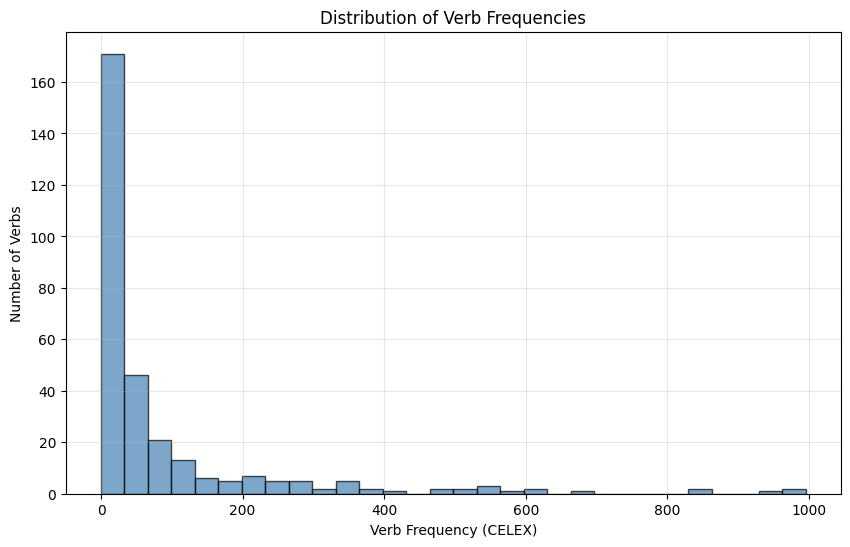

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df_verbs['frequency'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Verb Frequency (CELEX)')
plt.ylabel('Number of Verbs')
plt.title('Distribution of Verb Frequencies')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import dataset_generator

# Prepare dataset to test the impact of word frequency
median_freq = df_verbs['frequency'].median()
df_verbs['freq_bin'] = np.where(df_verbs['frequency'] >= median_freq, 'high', 'low')

df_freq = dataset_generator.create_frequency_dataset(df_verbs)
dataset_generator.save_dataset(df_freq, 'frequency_dataset.tsv')

Saved dataset to: frequency_dataset.tsv


'frequency_dataset.tsv'

In [19]:
import dataset_generator_multiNP

median_freq = df_verbs['frequency'].median()
df_verbs['freq_bin'] = np.where(df_verbs['frequency'] >= median_freq, 'high', 'low')

df_freq_multi = dataset_generator_multiNP.create_frequency_dataset(df_verbs)
dataset_generator_multiNP.save_dataset(df_freq_multi, 'frequency_dataset_multiNP.tsv')

Saved dataset to: frequency_dataset_multiNP.tsv


'frequency_dataset_multiNP.tsv'

In [20]:
import dataset_generator_samegender

median_freq = df_verbs['frequency'].median()
df_verbs['freq_bin'] = np.where(df_verbs['frequency'] >= median_freq, 'high', 'low')

df_freq_same = dataset_generator_samegender.create_frequency_dataset(df_verbs)
dataset_generator_samegender.save_dataset(df_freq_same, 'frequency_dataset_same.tsv')

Saved dataset to: frequency_dataset_same.tsv


'frequency_dataset_same.tsv'

In [21]:
# Prepare dataset to test the impact of semantic class
# df_verbs['ic'] = np.where(df_verbs['bias'] >= 0, 'NP1', 'NP2')

df_semantic = dataset_generator.create_semantic_dataset(df_verbs)
dataset_generator.save_dataset(df_semantic, 'semantic_dataset.tsv')

Saved dataset to: semantic_dataset.tsv


'semantic_dataset.tsv'

In [22]:
df_semantic_multi = dataset_generator_multiNP.create_semantic_dataset(df_verbs)
dataset_generator_multiNP.save_dataset(df_semantic_multi, 'semantic_dataset_multiNP.tsv')

Saved dataset to: semantic_dataset_multiNP.tsv


'semantic_dataset_multiNP.tsv'

In [23]:
df_semantic_same = dataset_generator_samegender.create_semantic_dataset(df_verbs)
dataset_generator_samegender.save_dataset(df_semantic_same, 'semantic_dataset_same.tsv')

Saved dataset to: semantic_dataset_same.tsv


'semantic_dataset_same.tsv'

## Results from the experiment
In this section, display the results required to answer your question. This can be in the format of a dataframe with just the required rows, or as a plot. 

          verb  frequency      diff
0    abandoned          2 -0.008566
1      abashed          0  0.017842
2     abhorred          3 -0.027221
3    acclaimed         35 -0.028322
4  accompanied         36  0.075878


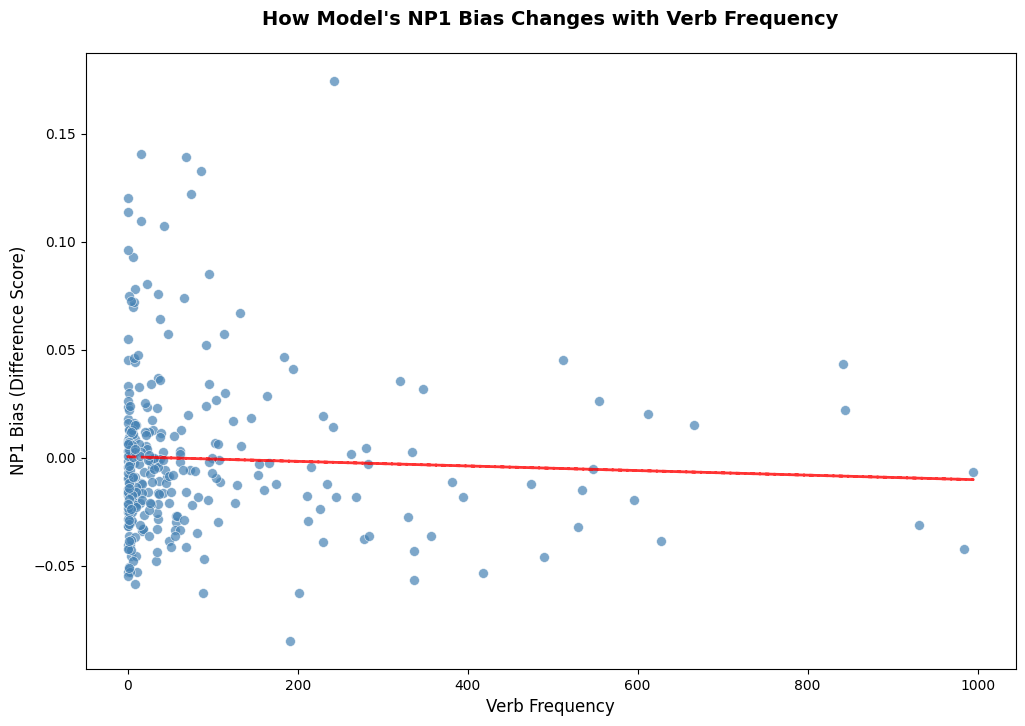

In [24]:
# Frequency
df_freq_bypair = pd.read_csv('results/frequency_dataset_bypair.tsv', sep='\t')
df_freq_expected = df_freq[df_freq['comparison'] == 'expected'].copy()

merged_df = pd.merge(df_freq_expected, df_freq_bypair, on='pairid', how='left')
merged_df = merged_df.groupby(['verb', 'frequency'], as_index=False)['diff'].mean()
print(merged_df.head())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(merged_df['frequency'], merged_df['diff'], 
                     alpha=0.7, s=50, c='steelblue', edgecolors='white', linewidth=0.5)

z = np.polyfit(merged_df['frequency'], merged_df['diff'], 1)
p = np.poly1d(z)
plt.plot(merged_df['frequency'], p(merged_df['frequency']), "r--", alpha=0.8, linewidth=2)

plt.xlabel('Verb Frequency', fontsize=12)
plt.ylabel('NP1 Bias (Difference Score)', fontsize=12)
plt.title('How Model\'s NP1 Bias Changes with Verb Frequency', fontsize=14, fontweight='bold', pad=20)

plt.show()

          verb  frequency      diff
0    abandoned          2  0.008590
1      abashed          0  0.006015
2     abhorred          3  0.000350
3    acclaimed         35  0.006456
4  accompanied         36  0.005727


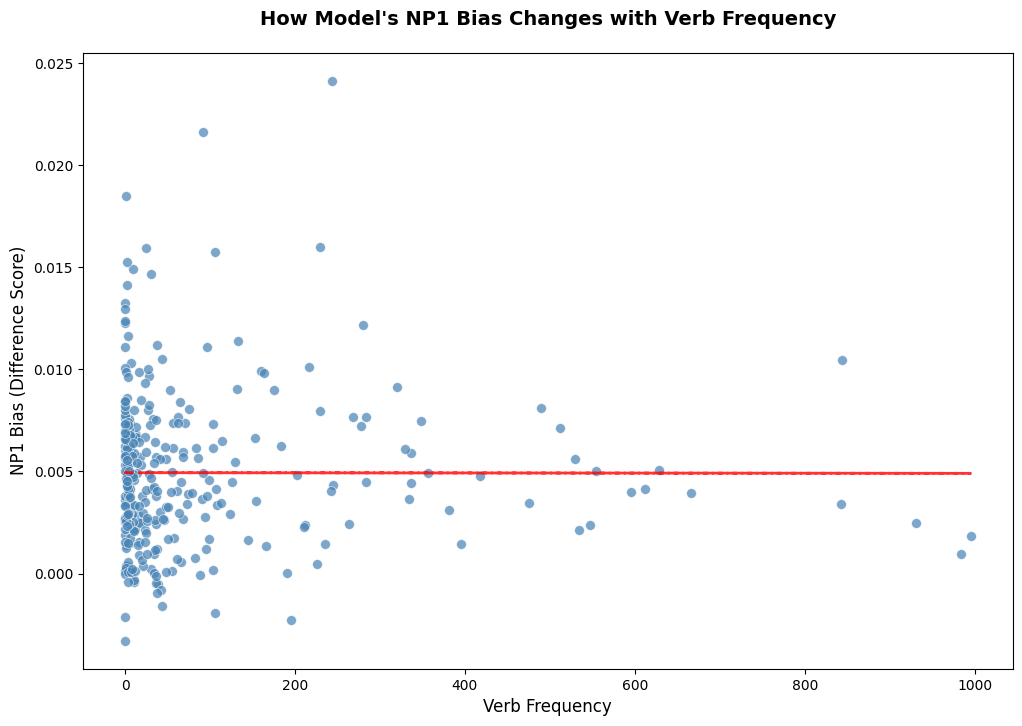

In [25]:
df_freq_multi_bypair = pd.read_csv('results/frequency_multiNP_bypair.tsv', sep='\t')
df_freq_multi_expected = df_freq_multi[df_freq_multi['comparison'] == 'expected'].copy()
merged_df = pd.merge(df_freq_multi_bypair, 
                        df_freq_multi_expected [['pairid', 'frequency', 'verb']], 
                        on='pairid', 
                        how='left')
# group by verb and average the diff scores
merged_df = merged_df.groupby(['verb', 'frequency'], as_index=False)['diff'].mean()

print(merged_df.head())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(merged_df['frequency'], merged_df['diff'], 
                     alpha=0.7, s=50, c='steelblue', edgecolors='white', linewidth=0.5)

z = np.polyfit(merged_df['frequency'], merged_df['diff'], 1)
p = np.poly1d(z)
plt.plot(merged_df['frequency'], p(merged_df['frequency']), "r--", alpha=0.8, linewidth=2)

plt.xlabel('Verb Frequency', fontsize=12)
plt.ylabel('NP1 Bias (Difference Score)', fontsize=12)
plt.title('How Model\'s NP1 Bias Changes with Verb Frequency', fontsize=14, fontweight='bold', pad=20)

plt.show()

          verb  frequency      diff
0    abandoned          2  0.002445
1      abashed          0  0.005493
2     abhorred          3 -0.000445
3    acclaimed         35  0.009094
4  accompanied         36  0.003362


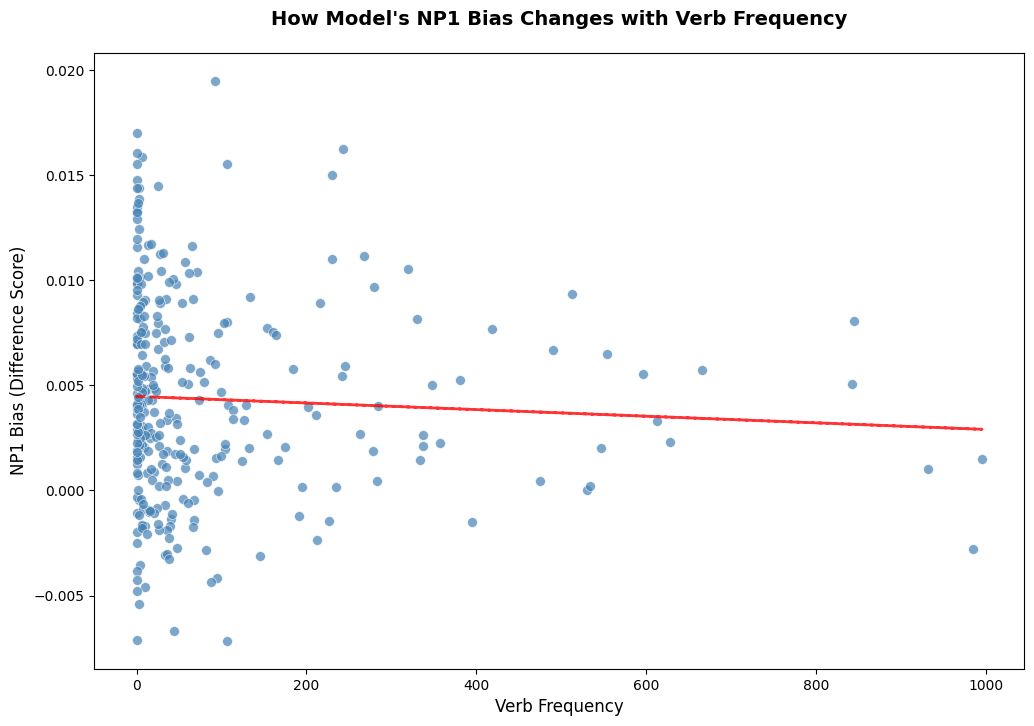

In [26]:
df_freq_same_bypair = pd.read_csv('results/frequency_same_bypair.tsv', sep='\t')
df_freq_same_expected = df_freq_same[df_freq_same['comparison'] == 'expected'].copy()
merged_df = pd.merge(df_freq_same_bypair, 
                        df_freq_same_expected [['pairid', 'frequency', 'verb']], 
                        on='pairid', 
                        how='left')
# group by verb and average the diff scores
merged_df = merged_df.groupby(['verb', 'frequency'], as_index=False)['diff'].mean()

print(merged_df.head())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(merged_df['frequency'], merged_df['diff'], 
                     alpha=0.7, s=50, c='steelblue', edgecolors='white', linewidth=0.5)

z = np.polyfit(merged_df['frequency'], merged_df['diff'], 1)
p = np.poly1d(z)
plt.plot(merged_df['frequency'], p(merged_df['frequency']), "r--", alpha=0.8, linewidth=2)

plt.xlabel('Verb Frequency', fontsize=12)
plt.ylabel('NP1 Bias (Difference Score)', fontsize=12)
plt.title('How Model\'s NP1 Bias Changes with Verb Frequency', fontsize=14, fontweight='bold', pad=20)

plt.show()

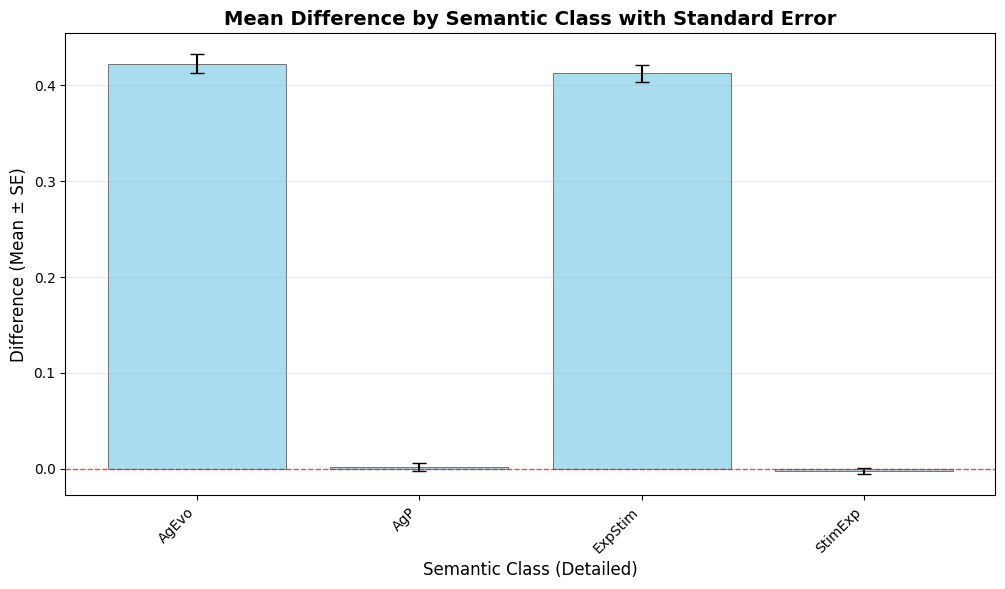

In [27]:
# semantic class
df_semantic_bypair = pd.read_csv('results/semantic_dataset_bypair.tsv', sep='\t')

grouped_stats = df_semantic_bypair.groupby('semantic_class_detailed')['diff'].agg([
    'mean', 
    'std', 
    'count'
]).reset_index()

grouped_stats['se'] = grouped_stats['std'] / np.sqrt(grouped_stats['count'])

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(grouped_stats)), 
               grouped_stats['mean'], 
               yerr=grouped_stats['se'],
               capsize=5,
               alpha=0.7,
               color='skyblue',
               edgecolor='black',
               linewidth=0.5)

plt.xlabel('Semantic Class (Detailed)', fontsize=12)
plt.ylabel('Difference (Mean ± SE)', fontsize=12)
plt.title('Mean Difference by Semantic Class with Standard Error', fontsize=14, fontweight='bold')
plt.xticks(range(len(grouped_stats)), 
           grouped_stats['semantic_class_detailed'], 
           rotation=45, 
           ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.show()


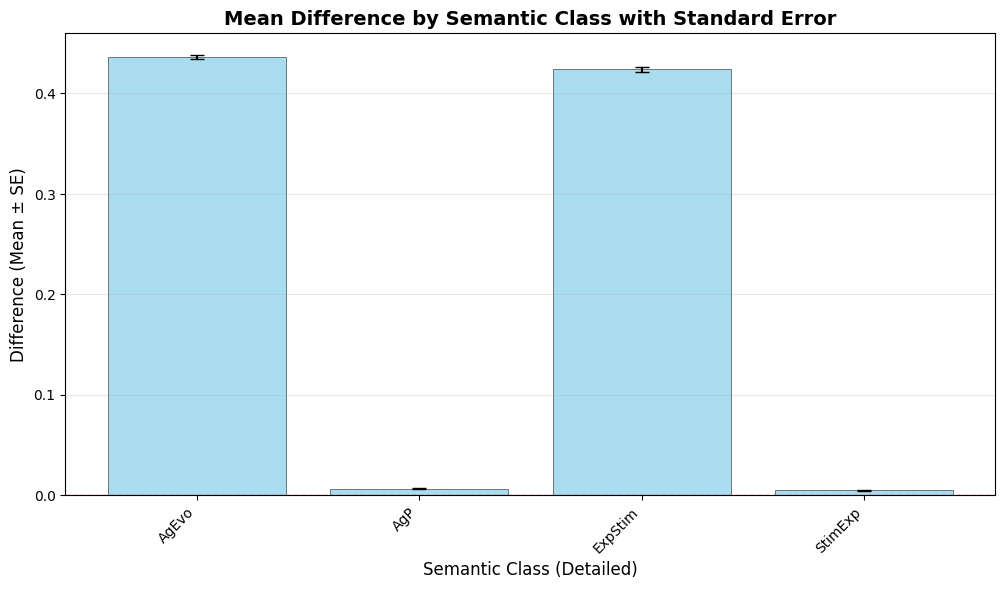

In [28]:
# semantic class
df_semantic_bypair = pd.read_csv('results/semantic_multiNP_bypair.tsv', sep='\t')

grouped_stats = df_semantic_bypair.groupby('semantic_class_detailed')['diff'].agg([
    'mean', 
    'std', 
    'count'
]).reset_index()

grouped_stats['se'] = grouped_stats['std'] / np.sqrt(grouped_stats['count'])

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(grouped_stats)), 
               grouped_stats['mean'], 
               yerr=grouped_stats['se'],
               capsize=5,
               alpha=0.7,
               color='skyblue',
               edgecolor='black',
               linewidth=0.5)

plt.xlabel('Semantic Class (Detailed)', fontsize=12)
plt.ylabel('Difference (Mean ± SE)', fontsize=12)
plt.title('Mean Difference by Semantic Class with Standard Error', fontsize=14, fontweight='bold')
plt.xticks(range(len(grouped_stats)), 
           grouped_stats['semantic_class_detailed'], 
           rotation=45, 
           ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.show()

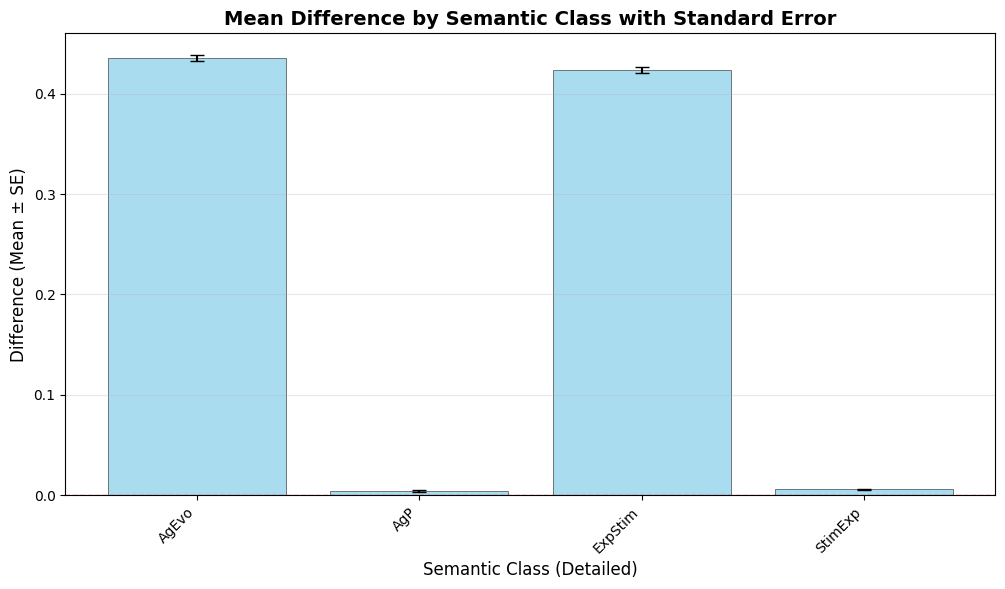

In [29]:
# semantic class
df_semantic_bypair = pd.read_csv('results/semantic_same_bypair.tsv', sep='\t')

grouped_stats = df_semantic_bypair.groupby('semantic_class_detailed')['diff'].agg([
    'mean', 
    'std', 
    'count'
]).reset_index()

grouped_stats['se'] = grouped_stats['std'] / np.sqrt(grouped_stats['count'])

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(grouped_stats)), 
               grouped_stats['mean'], 
               yerr=grouped_stats['se'],
               capsize=5,
               alpha=0.7,
               color='skyblue',
               edgecolor='black',
               linewidth=0.5)

plt.xlabel('Semantic Class (Detailed)', fontsize=12)
plt.ylabel('Difference (Mean ± SE)', fontsize=12)
plt.title('Mean Difference by Semantic Class with Standard Error', fontsize=14, fontweight='bold')
plt.xticks(range(len(grouped_stats)), 
           grouped_stats['semantic_class_detailed'], 
           rotation=45, 
           ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.show()

## Discussion

### Experimental materials

Our experiment employs three distinct dataset generation approaches, each designed to test different aspects of pronoun resolution and gender bias:

1. **Basic Template** (`dataset_generator.py`): Single random name combinations
2. **Multi-NP Template** (`dataset_generator_multiNP.py`): Exhaustive name combinations with gender mismatch manipulation
3. **Same-Gender Template** (`dataset_generator_samegender.py`): Gender congruence manipulation (remove test cases where the pronoun at ROI mismatches with either of the NPs)

The multi-NP template is scientifically valuable because it:

- Rather than using random name selection, it systematically tests all possible name combinations, ensuring comprehensive coverage of gender configurations
- The exhaustive approach generates more data points per verb, improving our ability to detect subtle effects
- Results that hold across all name combinations are more likely to represent genuine linguistic phenomena rather than artifacts of specific name choices

#### Research Questions and Findings

##### 1. How does the model's NP1 bias change with verb frequency?

Our analysis across all three experimental templates reveals a weak relationship between verb frequency and NP1 bias strength. The Model showed **slightly higher NP1 bias for low-frequency verbs** compared to high-frequency verbs.

**Limitations:**
Our verb frequency dataset was **unevenly distributed**, potentially limiting our ability to detect stronger frequency effects

##### 2. Do activity verbs have a weaker bias than psychological verbs?

Contrary to our initial hypothesis, **psychological verbs did not show stronger biases than activity verbs**. In fact, our results demonstrate the opposite pattern. **Activity verbs (AgEvo class) showed larger biases** than psychological verbs (ExpStim class). The Model can hardly tell a bias for AgP and StimExp classes (typically NP1 bias).

#### DistilGPT's Limitations

**Consistent NP2 Bias Performance:**
- DistilGPT demonstrates **NP2 bias** across different verb types and experimental conditions
- This consistency suggests the model has learned systematic patterns for NP2-pronoun coreference

**Poor NP1 Bias Performance:**
- The model shows **weak NP1 bias**, even for verb classes that should theoretically favor NP1 coreference
- This asymmetry indicates **incomplete learning** of pronoun resolution strategies

This asymmetric performance pattern represents a significant concern for incomplete linguistic xompetence and limited generalization.